# SSE Detection Figures

## Outputs

- Figure files and table exports under `sse_detection/figures`

In [1]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "config.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils import (  # noqa: E402
    save_figure,
    WIDTHS,
    )

from sse_detection import lib as sselib  # noqa: E402


OUTPUT_DIR = PROJECT_ROOT / "sse_detection" / "results" / "sse_outputs"
FIG_DIR = PROJECT_ROOT / "sse_detection" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SAVE_FIGURES = True

def save_plot(
    plot,
    stem,
    width: WIDTHS = "double",
    width_in=None,
    height_in=None,
    
):
    if not SAVE_FIGURES:
        return
    save_figure(
        plot,
        FIG_DIR / stem,
        width=width,
        width_in=width_in,
        height_in=height_in,
        save_pdf=True,
        save_png=True,
    )

## Load Outputs

`load_sse_outputs` returns a container with the static parquet tables: `node_stats`, `edge_table`, `candidate_review`, `meta_summary`.

In [2]:
outs = sselib.load_sse_outputs(OUTPUT_DIR)
node_stats = outs.node_stats
min_size = node_stats[node_stats["sse_candidate"]]["cluster_size"].min()
edge_table = outs.edge_table
candidate_review = outs.candidate_review
meta_summary = outs.meta_summary
candidates = outs.candidates

print(f"node_stats: {node_stats.shape[0]:,} rows x {node_stats.shape[1]:,} columns")
print(f"edge_table: {edge_table.shape[0]:,} rows")
print(f"candidate nodes: {len(candidates):,}")
print(f"min candidate cluster size: {min_size}")
print(f"background nodes: {(node_stats['cluster_size'].ge(min_size)).sum() - len(candidates):,}")

node_stats: 99,006 rows x 160 columns
edge_table: 41,747 rows
candidate nodes: 6,907
min candidate cluster size: 6
background nodes: 6,152


## Output Summary Table

In [3]:
summary = pd.DataFrame(
    [
        ("node-clusters", len(node_stats)),
        ("directed edges", len(edge_table)),
        ("meta-clusters", meta_summary["meta_cluster_id"].nunique()),
        ("SSE-like candidate nodes", int(node_stats["sse_candidate"].sum())),
        ("candidate share of nodes", float(node_stats["sse_candidate"].mean())),
        (f"background nodes (>= {min_size})", int(node_stats["cluster_size"].ge(min_size).sum() - node_stats["sse_candidate"].sum())),
        (f"background share of nodes (>= {min_size})", float(node_stats["cluster_size"].ge(min_size).mean() - node_stats["sse_candidate"].mean())),
        ("unique candidate categories", candidates["sse_category"].nunique()),
    ],
    columns=["quantity", "value"],
)

summary["display_value"] = summary["value"].map(
    lambda x: (
        f"{x:,.1%}"
        if isinstance(x, float) and x < 1
        else f"{x:,.0f}"
        if pd.notna(x)
        else "NA"
    )
)

display(summary[["quantity", "display_value"]])

,quantity,display_value
0,node-clusters,"99,006"
1,directed edges,"41,747"
2,meta-clusters,"57,354"
3,SSE-like candidate nodes,"6,907"
4,candidate share of nodes,7.0%
5,background nodes (>= 6),"6,152"
6,background share of nodes (>= 6),6.2%
7,unique candidate categories,8


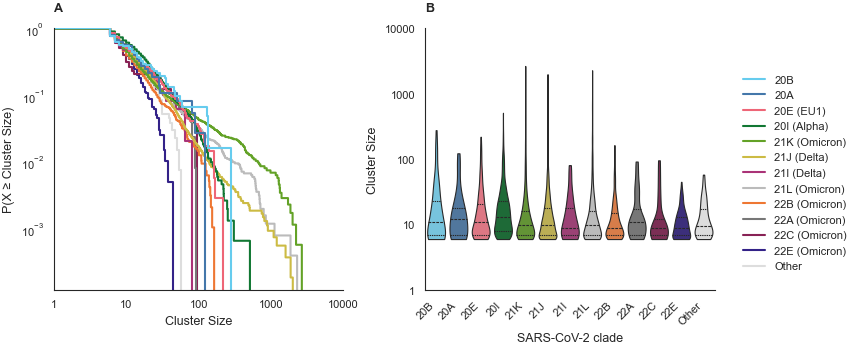

In [4]:
fig = sselib.plot_cluster_size_distribution(
    node_stats, min_size=min_size
)
display(fig)
save_plot(fig, "fig01_cluster_size",  height_in=3.5)

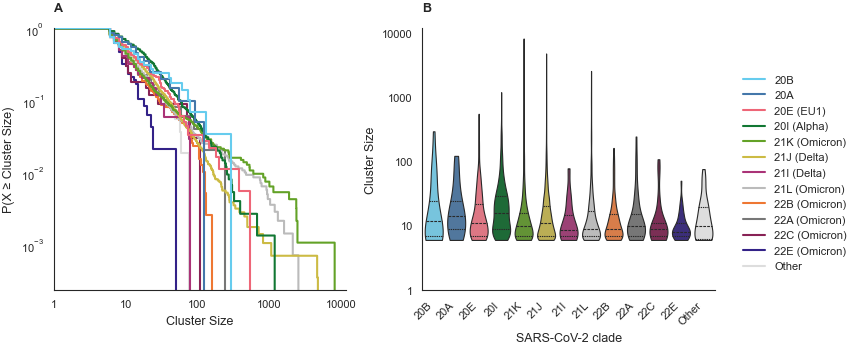

In [5]:
fig = sselib.plot_cluster_size_distribution(
    meta_summary, size_col="n_sequences", min_size=min_size
)
display(fig)
save_plot(fig, "fig02_meta_cluster_size", height_in=3.5)

In [6]:
sse_roles = node_stats["sse_role"].dropna().unique()

role_summary = (
    node_stats
    .groupby("meta_cluster_id")["sse_role"]
    .nunique()
    .reset_index(name="n_roles_represented")
)

max_roles = role_summary["n_roles_represented"].max()

meta_ids = role_summary[
    role_summary["n_roles_represented"] == max_roles
    ]["meta_cluster_id"].tolist()

meta_ids

['AM00001',
 'AM00002',
 'AM00007',
 'AM00009',
 'AM00011',
 'AM00012',
 'AM00015',
 'AM00027',
 'AM00028',
 'AM00032',
 'AM00049',
 'AM00062',
 'AM00088',
 'AM00100',
 'AM00140',
 'AM00142',
 'AM00206',
 'AM00207',
 'AM00287',
 'AM00418',
 'AM00420',
 'AM00707',
 'AM01344',
 'AM01358']

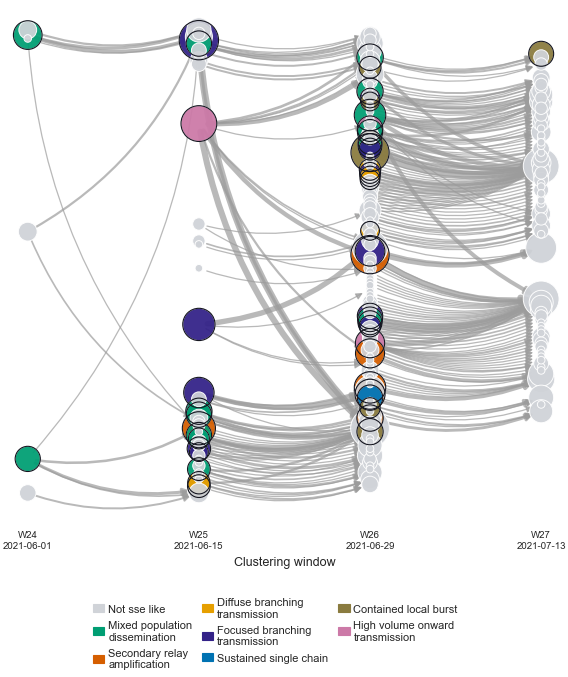

In [7]:
show = True
for meta_id in meta_ids[:10]:
    fig = sselib.plot_meta_cluster_subgraph(
        node_stats=node_stats,
        edge_table=edge_table,
        meta_cluster_id=meta_id,
        color_by="sse_category",
        annotate_top_n=0,
        rankdir="LR",
        height_in=8,
    )
    if show:
        display(fig)
        show = False
    save_plot(fig, f"fig03_subgraph_{meta_id}_exemplar", height_in=7.0)

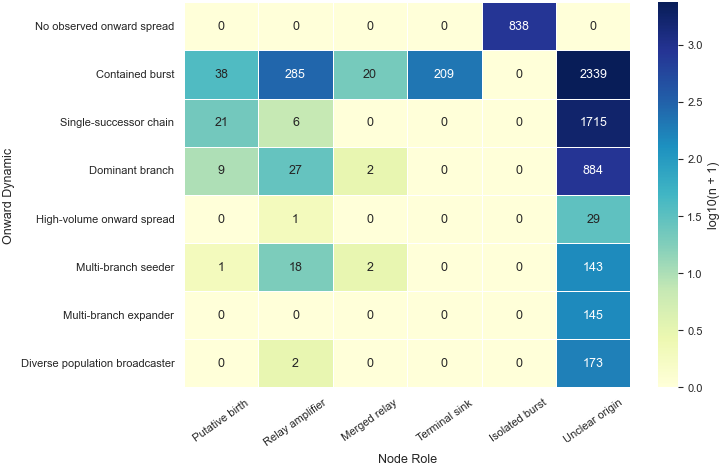

In [8]:
fig = sselib.plot_role_dynamic_heatmap(candidates)
display(fig)
save_plot(fig, "fig04_role_onward_heatmap", height_in=5)

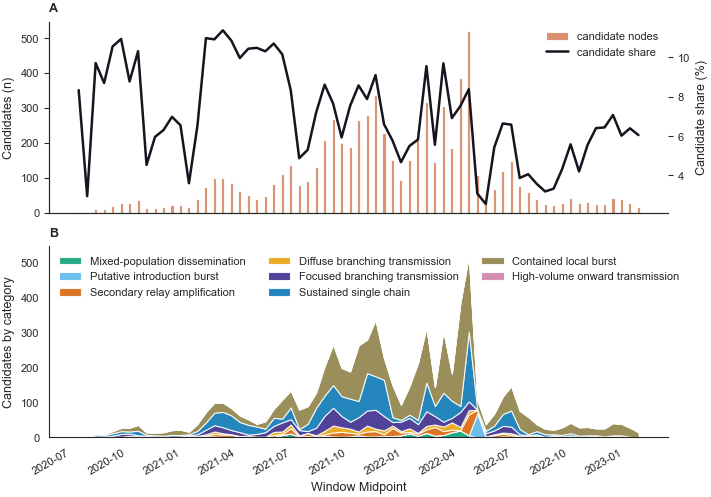

In [9]:
fig = sselib.plot_candidate_rate_over_time(node_stats)
display(fig)
save_plot(fig, "fig05_candidate_rate_over_time", height_in=5)

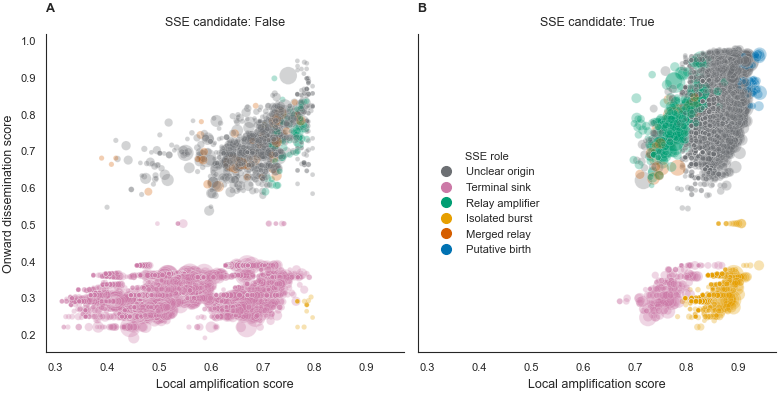

In [10]:
fig = sselib.plot_core_metric_space(node_stats, min_size=min_size, height_in=4)
display(fig)
save_plot(fig, "fig06_metric_space_scatter", height_in=4)

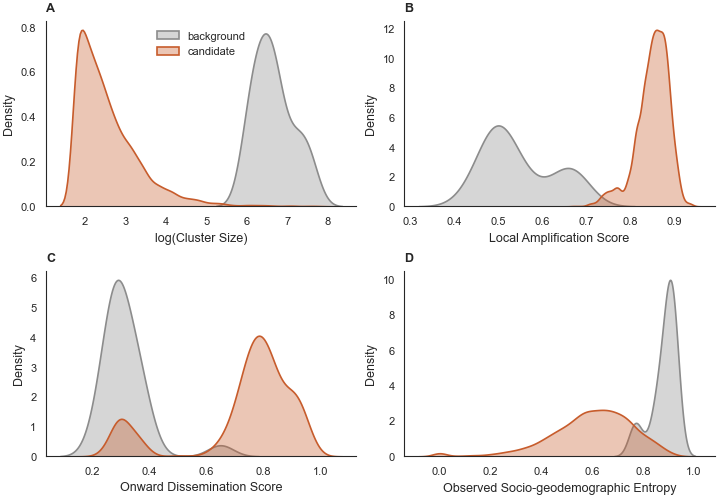

In [11]:
fig = sselib.plot_composite_distributions(node_stats, min_size=min_size, height_in=5)
display(fig)
save_plot(fig, "fig07_composite_score_distributions", height_in=5)

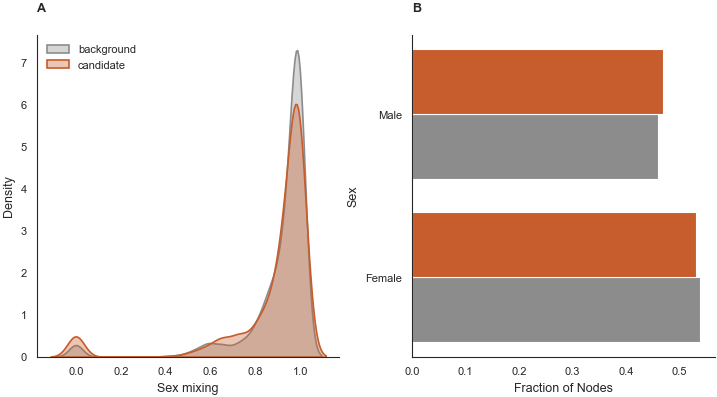

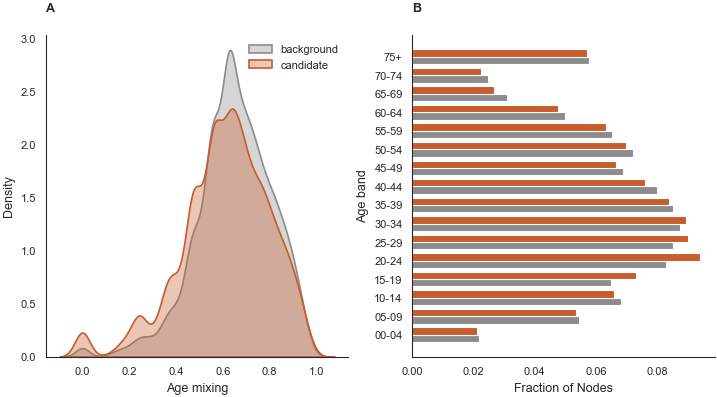

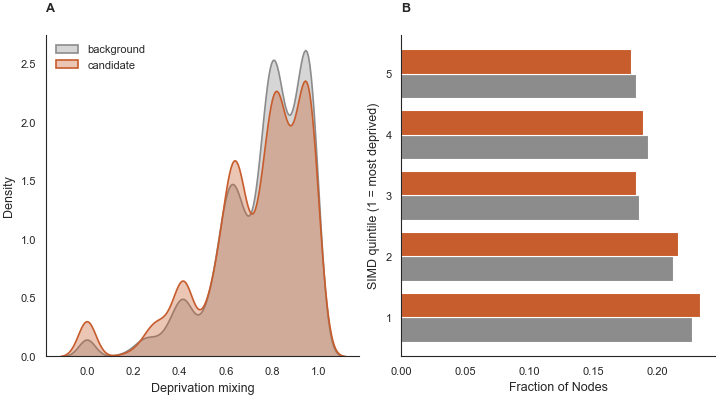

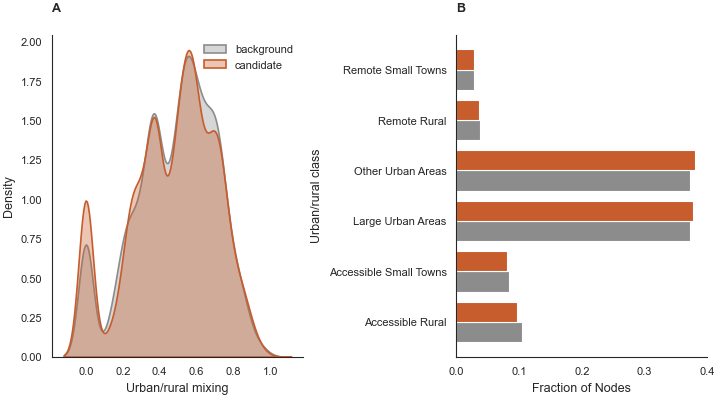

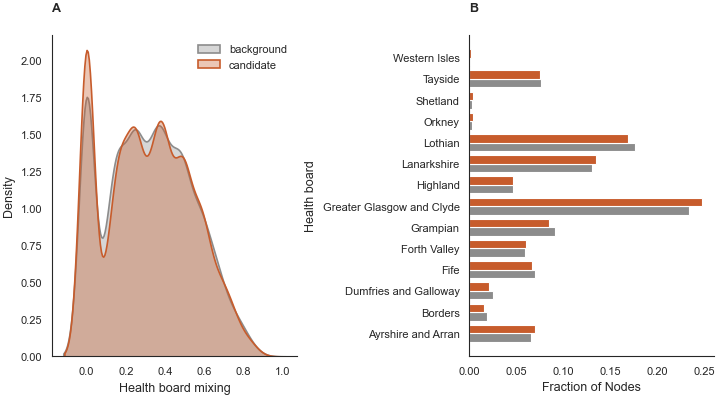

In [ ]:
socio_demo_cols = [
    ("sex_counts", "sex_entropy_obs", ("Sex mixing score", "Sex")),
    ("age_band_counts", "age_entropy_obs",("Age mixing score",  "Age band")),
    ("simd_quintile_counts","simd_entropy_obs", ("Socioeconomic mixing score", "SIMD quintile (1 = most deprived)")),
    ("urban_rural_class_counts",  "urban_rural_entropy_obs", ("Urban/rural mixing score", "Urban/rural class")),
    ("health_board_counts",  "health_board_entropy_obs", ("Health board mixing score", "Health board")),
]

for col, score, label in socio_demo_cols:

    fig, _ = sselib.plot_socio_demo_breakdown(
        node_stats, min_size=min_size,
        col=col,
        score=score,
        labels=label,
    )
    display(fig)
    save_plot(fig, f"fig08_{col}_{score}_breakdown", height_in=4)

## Regression Association Outputs

Load the saved association tables from `association_outputs` and render the regression figures and manuscript-facing summary tables produced by the new plotting helpers.

In [ ]:
# Load association outputs and generate manuscript tables/figures
ASSOCIATION_DIR = PROJECT_ROOT / "sse_detection" / "results" / "association_outputs"

# Presentational reference for mixing when missing in the CSVs
MIXING_REFERENCE = "\nper 1-SD null-model"

# Files we expect from the association notebook
files = [
    "composition_wald.csv",
    "composition_odds_ratios.csv",
    "composition_fit_stats.csv",
    "mixing_wald.csv",
    "mixing_odds_ratios.csv",
    "mixing_fit_stats.csv",
]

association_tables = {}
for fname in files:
    path = ASSOCIATION_DIR / fname
    if not path.exists():
        print(f"missing {fname}: {path}")
        continue
    df = pd.read_csv(path, skipinitialspace=True)
    # normalize column names and string columns
    df.columns = [c.strip() for c in df.columns]
    for col in df.select_dtypes(include=["object","string"]).columns:
        present = df[col].notna()
        df.loc[present, col] = df.loc[present, col].astype(str).str.strip()
    association_tables[fname] = df

composition_wald = association_tables.get("composition_wald.csv", pd.DataFrame())
composition_or = association_tables.get("composition_odds_ratios.csv", pd.DataFrame())
composition_fit = association_tables.get("composition_fit_stats.csv", pd.DataFrame())
mixing_wald = association_tables.get("mixing_wald.csv", pd.DataFrame())
mixing_or = association_tables.get("mixing_odds_ratios.csv", pd.DataFrame())
mixing_fit = association_tables.get("mixing_fit_stats.csv", pd.DataFrame())

# Build manuscript tables using sselib helpers
composition_wald_table = sselib.make_regression_wald_table(composition_wald, domain="composition")
composition_or_table = sselib.make_regression_odds_ratio_table(composition_or, domain="composition")
composition_fit_table = sselib.make_regression_fit_table(composition_fit, domain="composition")

mixing_wald_table = sselib.make_regression_wald_table(mixing_wald, domain="node_mixing")
mixing_or_table = sselib.make_regression_odds_ratio_table(mixing_or, domain="node_mixing")
mixing_fit_table = sselib.make_regression_fit_table(mixing_fit, domain="node_mixing")

# Ensure mixing tables have a sensible reference text if missing
for table in (mixing_wald_table, mixing_or_table, mixing_fit_table):
    if table.empty:
        continue
    if "Reference/scale" in table.columns:
        table["Reference/scale"] = table["Reference/scale"].fillna(MIXING_REFERENCE)
    elif "reference" in table.columns:
        table["reference"] = table["reference"].fillna(MIXING_REFERENCE)
    else:
        table["reference"] = MIXING_REFERENCE

# Save manuscript tables to figures directory
composition_wald_table.to_csv(FIG_DIR / "composition_wald_table.csv", index=False)
composition_or_table.to_csv(FIG_DIR / "composition_or_table.csv", index=False)
composition_fit_table.to_csv(FIG_DIR / "composition_fit_table.csv", index=False)
mixing_wald_table.to_csv(FIG_DIR / "mixing_wald_table.csv", index=False)
mixing_or_table.to_csv(FIG_DIR / "mixing_or_table.csv", index=False)
mixing_fit_table.to_csv(FIG_DIR / "mixing_fit_table.csv", index=False)

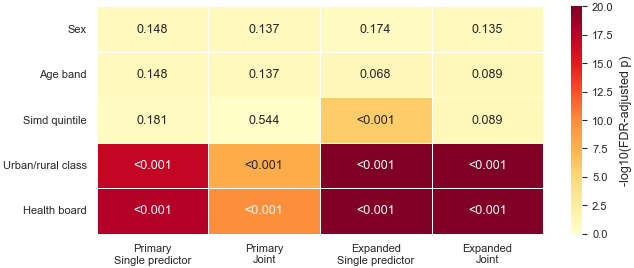

In [4]:
fig = sselib.plot_regression_wald_heatmap(composition_wald)
display(fig)
save_plot(fig, "fig09_composition_wald_heatmap")

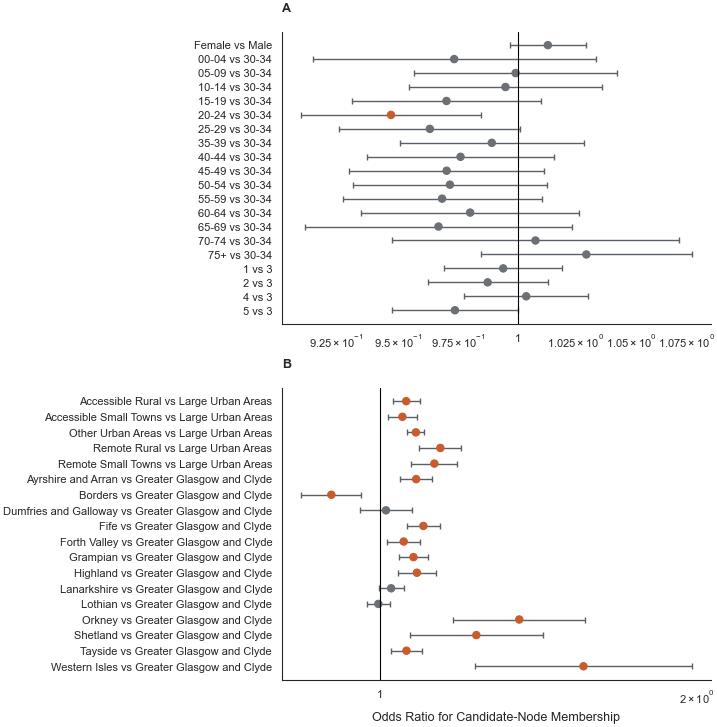

In [5]:
fig = sselib.plot_regression_odds_ratio_forest(composition_or)
display(fig)
save_plot(fig, "fig10_composition_or_forest")

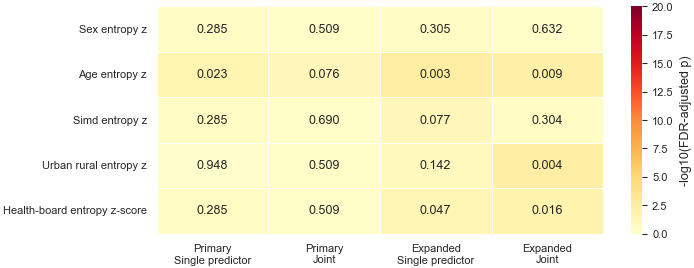

In [6]:
fig = sselib.plot_regression_wald_heatmap(mixing_wald)
display(fig)
save_plot(fig, "fig11_mixing_wald_heatmap")

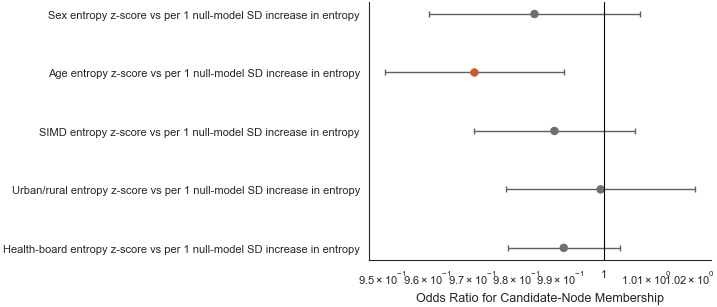

In [7]:
fig = sselib.plot_regression_odds_ratio_forest(mixing_or)
display(fig)
save_plot(fig, "fig12_mixing_or_forest")

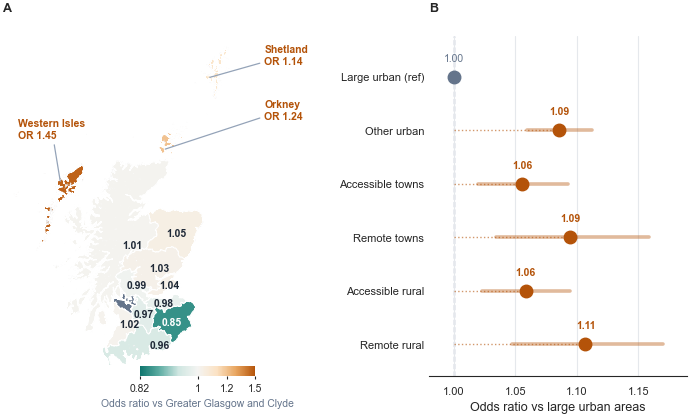

In [ ]:
GEOGRAPHY_PATH = PROJECT_ROOT / "data" / "processed" / "scotland_geography.parquet"
RESULTS_DIR = PROJECT_ROOT / "sse_detection" / "results"

fig = sselib.plot_health_board_enrichment_map(
    GEOGRAPHY_PATH,
    composition_or,
)
display(fig)
save_plot(fig, "fig13_healthboard_map")

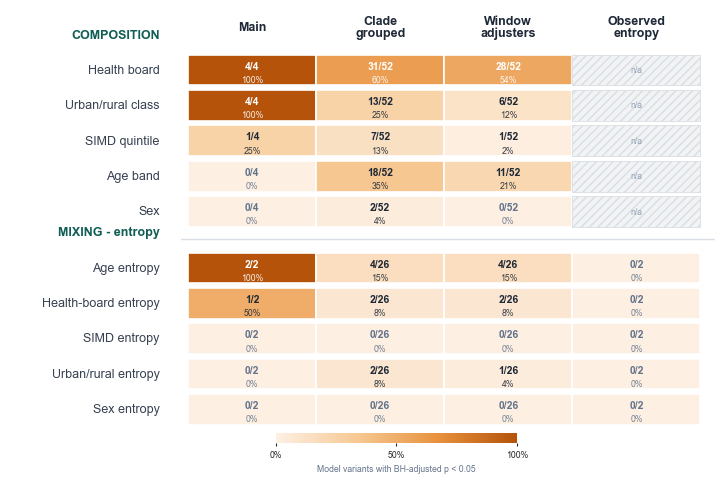

In [9]:
fig = sselib.plot_sensitivity_matrix(RESULTS_DIR)
display(fig)
save_plot(fig, "fig14_sensitivity_matrix")